In [2]:
import pandas as pd 
import numpy as np
df = pd.read_csv("D:\\project hour\\World Cup\\results.csv")

teams = ["Canada","Mexico","United States","Australia","Iran","Japan","Jordan","South Korea","Qatar","Saudi Arabia","Uzbekistan","Algeria","Cabo Verde","Côte d'Ivoire","Egypt","Ghana","Morocco","Senegal","South Africa","Tunisia","Argentina","Brazil","Colombia","Ecuador","Paraguay","Uruguay","New Zealand","Austria","Belgium","Croatia","England","France","Germany","Netherlands","Norway","Portugal","Scotland","Spain","Switzerland","Sweden"]

df = df[df['home_team'].isin(teams) | df['away_team'].isin(teams)]

print(df.head(10))

         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England           0           0   Friendly  Glasgow   
1  1873-03-08   England  Scotland           4           2   Friendly   London   
2  1874-03-07  Scotland   England           2           1   Friendly  Glasgow   
3  1875-03-06   England  Scotland           2           2   Friendly   London   
4  1876-03-04  Scotland   England           3           0   Friendly  Glasgow   
5  1876-03-25  Scotland     Wales           4           0   Friendly  Glasgow   
6  1877-03-03   England  Scotland           1           3   Friendly   London   
7  1877-03-05     Wales  Scotland           0           2   Friendly  Wrexham   
8  1878-03-02  Scotland   England           7           2   Friendly  Glasgow   
9  1878-03-23  Scotland     Wales           9           0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    F

1. Model training

a. Missing data checking and handling

In [3]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# There are no missing values so no need to handle them, but if there
# were any the following code handles that 

home_medians = df.groupby('home_team')['home_score'].median()
df['home_score'] = df.apply(lambda row: home_medians[row['home_team']] if pd.isna(row['home_score']) else row['home_score'], axis=1)

away_medians = df.groupby('away_team')['away_score'].median()
df['away_score'] = df.apply(lambda row: away_medians[row['away_team']] if pd.isna(row['away_score']) else row['away_score'], axis=1)

non_goal_cols = [col for col in df.columns if col not in ['home_score', 'away_score']]
df.dropna(subset=non_goal_cols, inplace=True)

print("Data after missing value handling:")
print(df)

Missing values per column:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64
Data after missing value handling:
             date     home_team             away_team  home_score  away_score  \
0      1872-11-30      Scotland               England           0           0   
1      1873-03-08       England              Scotland           4           2   
2      1874-03-07      Scotland               England           2           1   
3      1875-03-06       England              Scotland           2           2   
4      1876-03-04      Scotland               England           3           0   
...           ...           ...                   ...         ...         ...   
48886  2025-12-12        Jordan                  Iraq           1           0   
48887  2025-12-12       Algeria  United Arab Emirates           1           1   
48888  2025-12-15       Morocco  United Arab Emirate

b. Duplicate data checking and handling

i. Dropping duplicate rows

ii. Unique value checking and replacing any possible entity

In [4]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

for col in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{col}': {df[col].unique()}")

Number of duplicate rows: 0
Shape after dropping duplicates: (22357, 9)

Unique values in 'date': ['1872-11-30' '1873-03-08' '1874-03-07' ... '2025-12-12' '2025-12-15'
 '2025-12-18']

Unique values in 'home_team': ['Scotland' 'England' 'Wales' 'Northern Ireland' 'United States' 'Uruguay'
 'Austria' 'Hungary' 'Argentina' 'Belgium' 'France' 'Netherlands'
 'Switzerland' 'Czechoslovakia' 'Sweden' 'Germany' 'Italy' 'Chile'
 'Norway' 'Finland' 'Luxembourg' 'Denmark' 'Catalonia' 'Russia' 'Brazil'
 'Japan' 'Paraguay' 'Spain' 'Egypt' 'Philippines' 'China PR' 'Canada'
 'Estonia' 'New Zealand' 'Portugal' 'Guatemala' 'Australia' 'Poland'
 'Brittany' 'Mexico' 'Yugoslavia' 'Latvia' 'Bolivia' 'Peru' 'Belarus'
 'Republic of Ireland' 'Bulgaria' 'Romania' 'Lithuania' 'Israel'
 'El Salvador' 'Panama' 'Colombia' 'Venezuela' 'Cuba' 'Ecuador' 'Slovakia'
 'Manchukuo' 'Croatia' 'India' 'Iceland' 'Iran' 'Turkey' 'Vietnam' 'Macau'
 'Greece' 'South Korea' 'Ghana' 'Zimbabwe' 'South Africa' 'New Caledonia'
 'Fiji'

c. Encoding approach [Categorical features only]

In [5]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nCategorical features encoded.")


Categorical features encoded.


d. Basic EDA

i. Graph plotting for numeric and categorical feature and their explanation

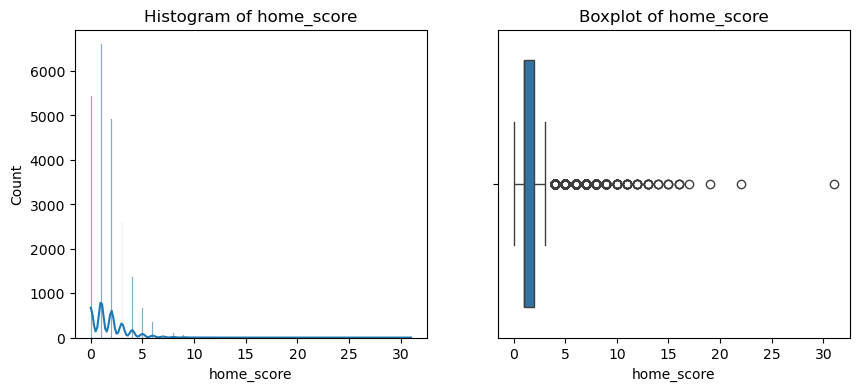

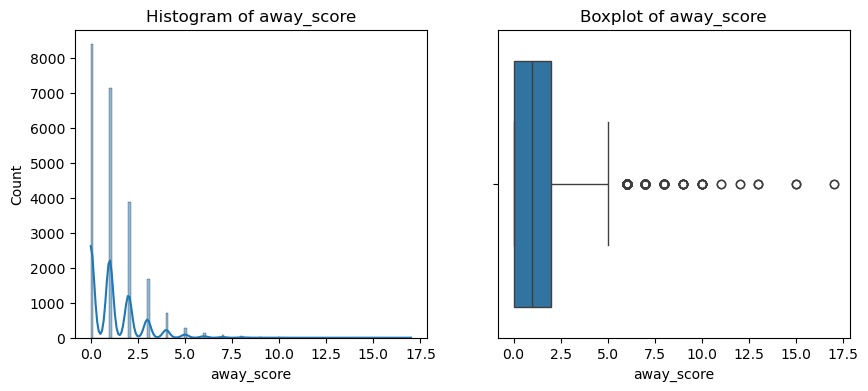

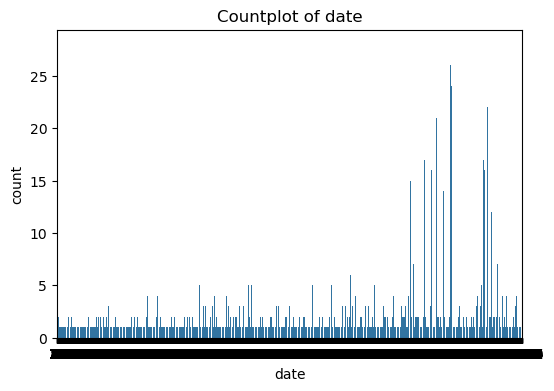

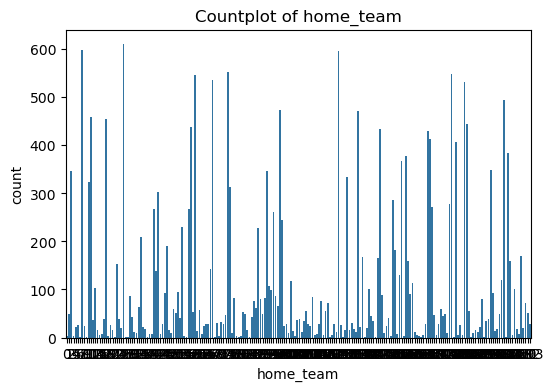

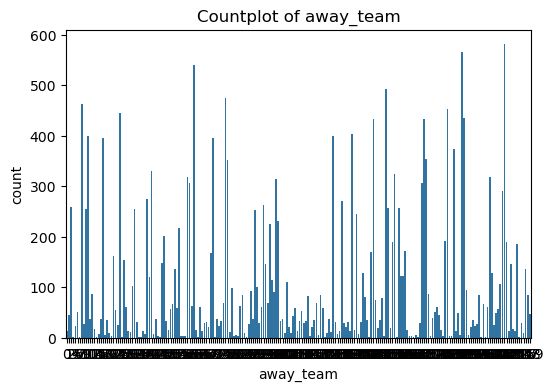

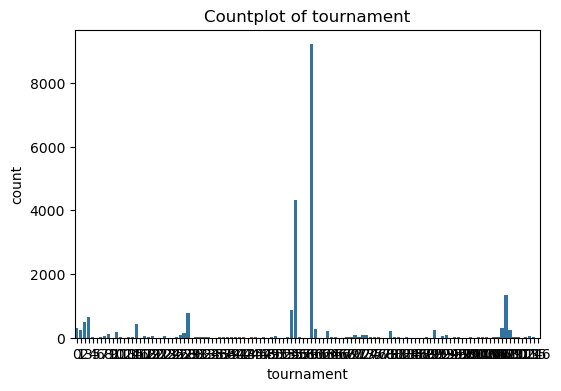

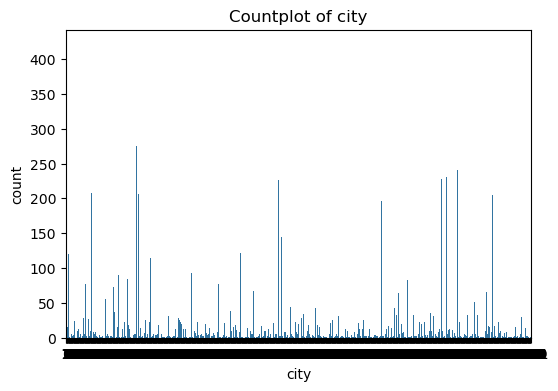

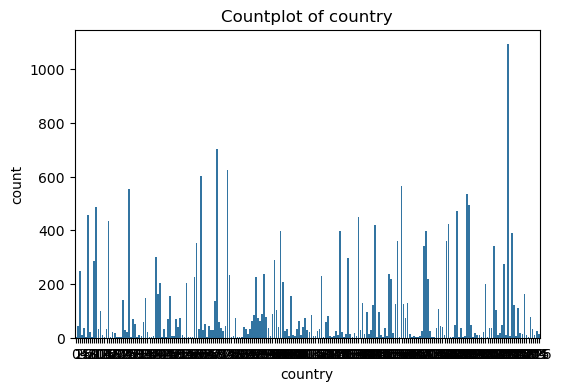

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.show()


d) ii. Can add basic static analysis (use of describe so can be used for further
comparison after outlier handling)

In [7]:
print("Numeric summary:")
print(df.describe())

print("\nCategorical summary (value counts):")
for col in cat_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

Numeric summary:
               date     home_team     away_team    home_score    away_score  \
count  22357.000000  22357.000000  22357.000000  22357.000000  22357.000000   
mean    6527.974505    107.932817    112.829628      1.723845      1.168135   
std     3050.628841     63.135479     64.753295      1.697158      1.342144   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%     4077.000000     56.000000     58.000000      1.000000      0.000000   
50%     7264.000000    103.000000    118.000000      1.000000      1.000000   
75%     9192.000000    167.000000    170.000000      2.000000      2.000000   
max    10553.000000    213.000000    219.000000     31.000000     17.000000   

         tournament          city       country  
count  22357.000000  22357.000000  22357.000000  
mean      55.521313    624.831283    117.298430  
std       25.717060    386.123432     66.940797  
min        0.000000      0.000000      0.000000  
25%       55.000000  

e. Outlier handling [Numeric features only]

i. Use boxplot of individual features for visualization.

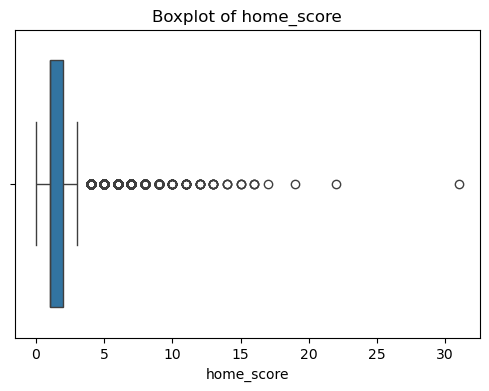

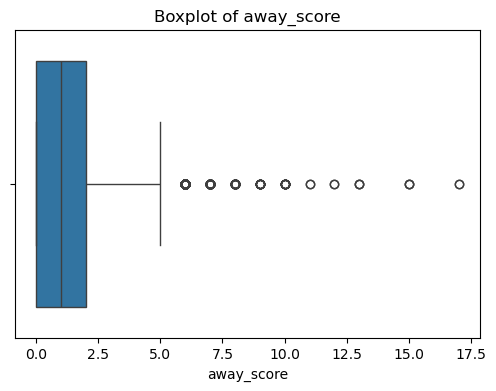

In [8]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


ii. Check multiple approaches then select the best one.

In [9]:
num_cols = ['home_score', 'away_score']

# 1. IQR capping
df_iqr = df.copy()
for col in num_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_iqr[col] = np.where(df_iqr[col] < lower, lower, df_iqr[col])
    df_iqr[col] = np.where(df_iqr[col] > upper, upper, df_iqr[col])

# 2. Z-score filtering (remove rows)
from scipy import stats
df_zscore = df[(np.abs(stats.zscore(df[num_cols])) < 3).all(axis=1)]

# 3. Winsorization (cap at 1st and 99th percentile)
from scipy.stats.mstats import winsorize
df_winsor = df.copy()
for col in num_cols:
    df_winsor[col] = winsorize(df_winsor[col], limits=[0.01, 0.01])

# Compare summaries
print("Original numeric summary:\n", df[num_cols].describe())
print("\nIQR capped summary:\n", df_iqr[num_cols].describe())
print("\nZ-score filtered summary:\n", df_zscore[num_cols].describe())
print("\nWinsorized summary:\n", df_winsor[num_cols].describe())

Original numeric summary:
          home_score    away_score
count  22357.000000  22357.000000
mean       1.723845      1.168135
std        1.697158      1.342144
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max       31.000000     17.000000

IQR capped summary:
          home_score    away_score
count  22357.000000  22357.000000
mean       1.522297      1.142461
std        1.199049      1.228487
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max        3.500000      5.000000

Z-score filtered summary:
          home_score    away_score
count  21686.000000  21686.000000
mean       1.613668      1.105368
std        1.427251      1.161289
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max        6.000000      5.000000

Wins

Discussion:

The original dataset has extreme outliers (home_score max = 31, away_score max = 17) that skew the mean and standard deviation. IQR capping reduces these extreme values to realistic ranges (home max ≈ 3.5, away max ≈ 5) without removing any rows. This preserves all matches, reduces noise from rare high-scoring games, and ensures the model learns typical score patterns. Therefore, IQR capping is the best approach for outlier handling in this dataset.

iii. Use only one outlier handling for model training.(Used IQR method)

In [10]:
#IQR method for outlier removal
import numpy as np

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers handled using IQR capping method.")

Outliers handled using IQR capping method.


f. Assigned Eda

All eda task have been completed and is in eda_tasks.ipynb file

g. Feature Engineering Task

Already completed in last number of eda_tasks.ipynb file

h. Utilization of feature reduction approach
i. Use of correlation(To remove highly correlated features [only for input not
the target])


In [11]:
print("Not enough numeric features to calculate correlation.")

Not enough numeric features to calculate correlation.


ii. PCA or any other method to further reduce the features.

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_numeric = df.drop(columns=['home_score', 'away_score']).select_dtypes(include=['int64','float64'])

if X_numeric.shape[1] == 0:
    print("No numeric input features available for PCA. Skipping PCA.")
else:
    X_scaled = StandardScaler().fit_transform(X_numeric)
    pca = PCA(n_components=0.95)
    X_pca = pca.fit_transform(X_scaled)
    print("Number of features after PCA:", X_pca.shape[1])

No numeric input features available for PCA. Skipping PCA.


i. Normality Test (Skewness Before Scaling)

In [13]:
import pandas as pd

# Numeric features
num_cols = ['home_score', 'away_score']

# Check skewness
print("Skewness before scaling:")
print(df[num_cols].skew())

Skewness before scaling:
home_score    0.271367
away_score    1.181453
dtype: float64


j. Scaling / Normalization (Numeric Features Only)

In [14]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# Save scaler for demo purposes
joblib.dump(scaler, "scaler.pkl")

print("Scaling completed and scaler saved.")

Scaling completed and scaler saved.


k. Normality Test After Scaling

In [15]:
print("Skewness after scaling:")
print(df_scaled[num_cols].skew())

Skewness after scaling:
home_score    0.271367
away_score    1.181453
dtype: float64


k.i Log1p Transformation for Highly Skewed Features

In [16]:
import numpy as np

skewness = df[num_cols].skew()

for col in num_cols:
    if abs(skewness[col]) > 1:  # threshold for high skew
        df[col] = np.log1p(df[col])
        print(f"Applied log1p transformation to {col}")

Applied log1p transformation to away_score


l. Model Training

In [17]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Example: predict home_score
X = df_scaled[['away_score']]  # input feature example
y = df_scaled['home_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


m. Model Evaluation

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model_lr.predict(X_test)

print("Model Evaluation (Linear Regression)")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Model Evaluation (Linear Regression)
MSE: 0.9644980514782953
R2 Score: 0.011687721781074023


m.i Train and Evaluate Another Model

In [20]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest Evaluation")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Evaluation
MSE: 0.9645726345231903
R2 Score: 0.011611297221269301


m.ii Save Model for Demo

In [21]:
import joblib

joblib.dump(model_lr, "linear_regression_model.pkl")
joblib.dump(model_rf, "random_forest_model.pkl")

print("Models saved successfully.")

Models saved successfully.
